In [1]:
# Frontal Collision Between Proca Objects with  n = 0, 1, 2  and a Soliton in the Ground State  n = 0 

In [1]:
cd ..

/Users/armandoroqueestrada/Library/Mobile Documents/com~apple~CloudDocs/GitHub/Euskera


In [2]:
import multiprocessing
import numpy as np
import euskera as eu

import matplotlib.pyplot as plt

In [3]:
### Referential multifrequency Profiles
Masa = 3.169156419812378/np.sqrt(2) # mass configuration
EProc = [2.531460403735335, 1.533816076750893, 1.0204220713087362] # energy eingevalue
fProca = [np.load(f'./Soliton Profile Files/initial_f{coord}.npz')['arr_0'] for coord in ['x', 'y', 'z']]

### Referential Profiles
# n = 0
En0 = 2.4538867992147075  # energy eingevalue
Mn0 = 5.491059312232425/np.sqrt(2)
fn0 = np.load('./Soliton Profile Files/initial_f_n0.npz')['arr_0']

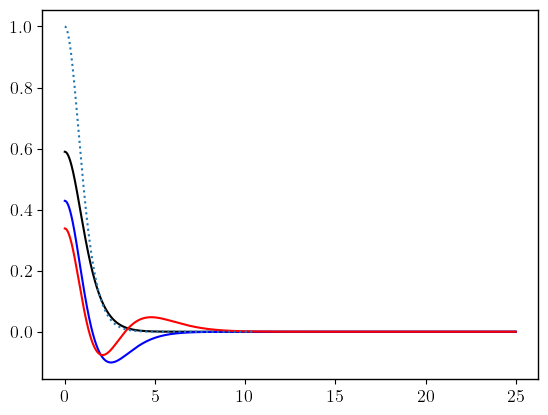

In [4]:
# Uncomment if you want to plot the profiles.
delta_r = 0.00001
rn = np.arange(len(fProca[0]))*delta_r
color = ['k', 'b', 'r']
for i,f in enumerate(fProca):
    plt.plot(rn, f, color[i])

rn = np.arange(len(fn0))*delta_r 
plt.plot(rn, fn0, ls=':')


In [5]:
#### identifying the cpu_processing number
num_threads = multiprocessing.cpu_count()  


#### Symulation Parameters
simulation_parameters = {
"lambda_value": 0,  # Self-interaction coupling constant.
"num_threads": num_threads,  # Set the number of threads to use.
"gridlength": 20,  # Length of the grid in codec units.
"resol": 150,  # Grid resolution. The grid is computed using:
               # linspace(-gridlength/2.0 + gridlength/(2.0*resol), 
               #           gridlength/2.0 - gridlength/(2.0*resol), resol).
"step_factor": 1.,  # Increase this if velocities are low enough that the timestep constraint can be relaxed.
"t0": 0,  # Initial time.
"tmax": 100,  # Total simulation time.
"Plim": 5.6,  # Boundary radius of the soliton.
"rmax": 7.6,  # Two rmax define the minimum separation between solitons 
              # to ensure they are not overlapping.
"cmass": 0,  # Central mass, given in the same units as the soliton mass.
"plott0": False,  # Show the initial profile if True.
"Boverlap": False,  # Check for possible overlap if True.
"methodEnerg": 1,  # methodology used to computed the kinetic contribution
"info": False  # Print extra information if True.
}

#### Save data information/parameters
salva_data = {
  "format": "npz",  # Format used to save data. Supported formats: "npz" and "hdf5".
  "address": "Data",  # Directory where the data will be saved.
  "save_number": 100,  # Number of frames to save within the time interval [t0, tmax].
  "data_save" : {"grid": True,  # Save grid data.
                 "save_rho": False,   # Save density field (ρ) if True.
                 "save_psi": False,  # Save wavefunction (ψ) if True.
                 "save_phi": True,  # Save potential (φ) if True.
                 "save_plane": True,  # Save plane projections  [:, :, resol/2,]] if True.
                 "save_energies": None,  # Save energy values if specified.
                 "save_line": True}  # Save 1D profile along a specific line [:, resol/2,, resol/2,]]  if True.
}


In [6]:
###### Used Model
modelS = "soliton"
nume_soliton = 2

###### Parameters for Components
compfield = 3  # Number of soliton components (for a scalar field: 1, for a vector field: 2, e.g., Ψ = [ψ_x, ψ_y], etc.)

# Component Profiles
sol1 = fProca  # If Ψ is a vector (e.g., Ψ = [ψ_x, ψ_y, ψ_z]), specify [fx, fy, fz].
solt2 = [fn0, np.zeros(len(sol1[0])), np.zeros(len(sol1[0]))]
solT = [sol1, solt2]

# Energy Eigenvalues for Each Component
beta1 = EProc  # If Ψ is a vector, specify [En0, En0].
beta2 = [En0, 0., 0.]
betaT = [beta1, beta2]

###### Configuration Parameters
# Central Positions (x0, y0, z0)
csol1 = [0., 0., 0.]
csol2 = [-4., 0., 0.]
csolT = [csol1, csol2]

# Velocities
vsol1 = [0., 0., 0.]
vsolT = [vsol1]*nume_soliton

# Phases
phase1 = [0.]
phaseT = [phase1]*nume_soliton

# Alpha values (only for the non-self-interacting case; otherwise, set to 1)
alpha = lambda massC, mass: (massC / mass) ** 2  # Conversion factor
alpha1 = [alpha(8, Mn0)]
alphaT = [alpha1]*nume_soliton

# Step size (dr) used to computed the radial profiles previusly
delta_r = 0.00001
dr1 = [delta_r]
drT = [dr1]*nume_soliton

In [7]:
parameters_sol = {
  modelS: [{"profiles": solT[i], "positions": csolT[i], "velocities": vsolT[i], "betas": betaT[i],
            "phases": phaseT[i], "alphas": alphaT[i], "dr": drT[i]} for i in range(0, nume_soliton)]
}

# Beginning the simulation
eu.evolve(model_parameters=parameters_sol,
           field_components=compfield,
           salva_data_update=salva_data,
           simulation_parameters_update=simulation_parameters,
           info=False)

Progress: [####################] 100%
 All data was save


Complete. Total time ->  2456.793739795685
save_frames 101 



In [ ]:
## Uncomment in case of load files individually
import os

address = salva_data["address"]
format = salva_data["format"]
save_number = salva_data["save_number"]

# Identifying the file names
filenames = eu.nameData(address, format, info=True)
print(filenames)

Found 4 files with the .npz extension.
['end_save_line.npz', 'end_save_plane.npz', 'end_save_phi.npz', 'end_grid.npz']


In [20]:
# extracting the grid coordinates
temp = np.load(address + f"/{filenames[-1]}")
grid = [temp[cord] for cord in ['x', 'y', 'z']]


# extracting the x-proyection of rho
temp = np.load(address + f"/{filenames[0]}")
lrho = [temp['save_line%s'%num] for num in range(0, save_number+1)]

temp = np.load(address + f"/{filenames[1]}")
planerho = [temp['save_plane%s'%num] for num in range(0, save_number+1)]

temp = np.load(address + f"/{filenames[2]}")
Upot = [temp['save_phi%s'%num] for num in range(0, save_number+1)]

(<Figure size 800x350 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

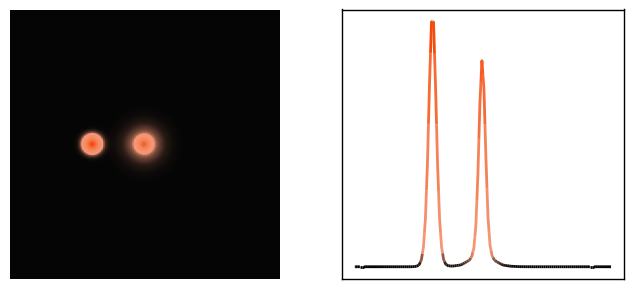

In [21]:
## Illustrative plots from the previusly load data

frame = 10
data = planerho[frame].T
da2 = [grid[0], lrho[frame]]

cmapint = [(0, '#050505'), (0.05, '#f59876'),
           (0.5, '#f57d51'), (0.75, '#f76834'),
           (1, '#f54a0c')]

eu.imagshow2D(data, da2, save=True, xlim=(-1, 1), ylim=(-1, 1), cmapint=cmapint)

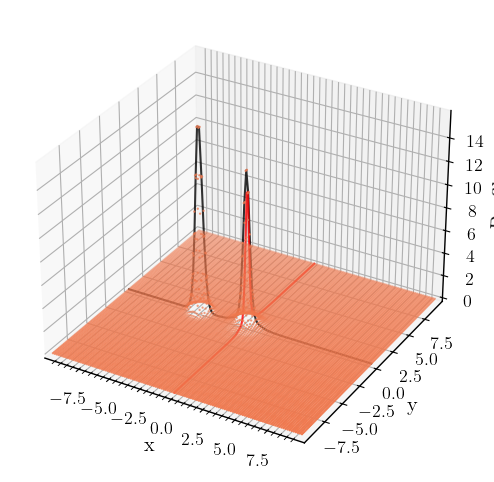

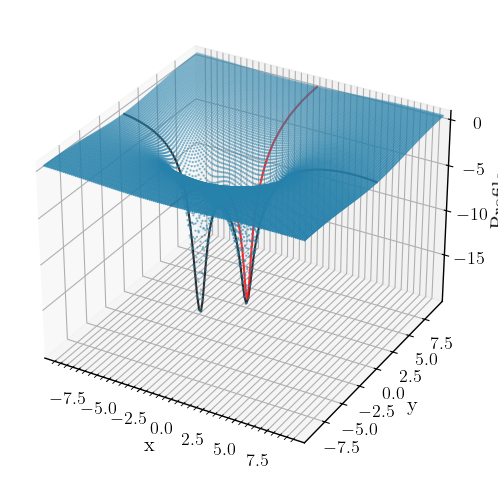

In [22]:
frame = 10
rho = planerho[frame]
phisp = Upot[frame]
xd, yd = grid[0], grid[1]
cxd, cyd = 'x', 'y'
resol = simulation_parameters['resol']

eu.PlaneProf(rho, xd, yd, cxd, cyd, save=False)  # density field
eu.PlaneProf(phisp[:, :, int(resol/2)], xd, yd, cxd, cyd, save=False)  # Potential field

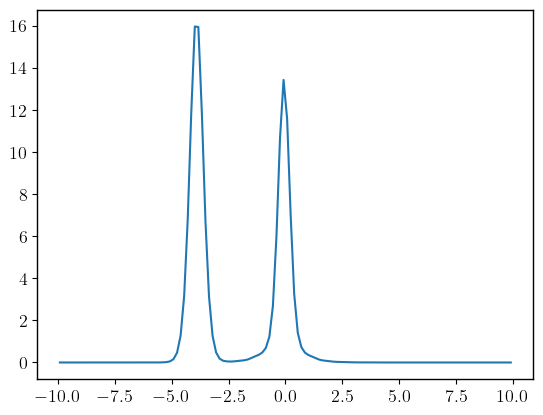

In [23]:
frame = 10
rho = lrho[frame]
xd = grid[0]

plt.plot(xd, rho)

In [ ]:
## Illustrative videos from the save data

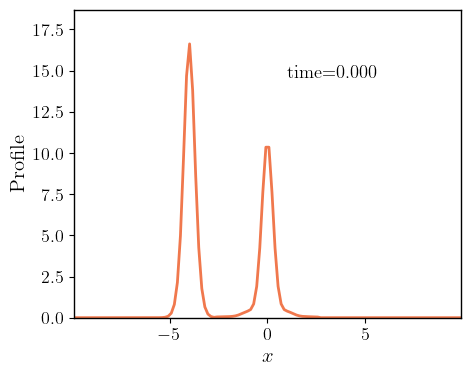

In [24]:
#Example of 2D video

#address = "Data_Est_n0_n0"
figData = plt.subplots(nrows=1, ncols=1, figsize=(5, 4), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

address = salva_data['address']
dvideo = eu.Visualization(address, figData)  # creando el objeto

n0 = 0  # begin frame
nameP = "save_line"
struc = ['-', 2, '#f0784d']
nameV = 'lin_dens'
coord = ['x']

video = dvideo.video(nameP, struc, nameV, coord=coord, 
                     xlim=None, ylim=None,
                     show=False, n0=n0, plot2D=True, 
                     plot3D=False, save=False)  # in case tha you like to save and not see in the notebook put save to True
display(video)

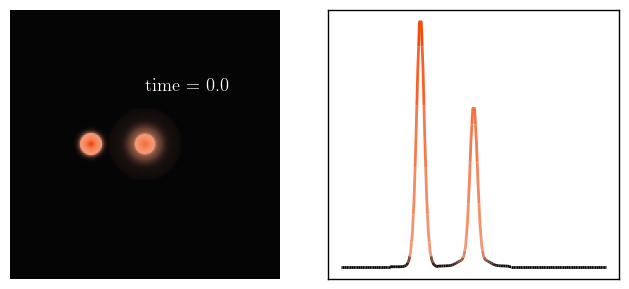

None

In [11]:
# Example of 2D video

#address = "Data_Est_n0_n0"
figData = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

dvideo = eu.Visualization(address, figData)  # making the object

n0 = 0  # begin frame
nameP = "save_line"
name2 = "save_plane"
struc = ['-', 2, '#f0784d']
nameV = 'front_coll_proca_solit'
coord = ['x']
cmapint=[(0, '#050505'),
         (0.05, '#f59876'),
         (0.5, '#f57d51'),
         (0.75, '#f76834'),
          (1, '#f54a0c')]
vconf = [3, 1000000, ['-vcodec', 'libx264']]

text = r' '

video = dvideo.video(nameP, struc, nameV, name2=name2, cmapint=cmapint,
                     coord=coord, show=True, n0=n0, plot2D=True, plot3D=False,
                     vconf=vconf, save=True,  # change to false if you like to see in the notebook
                     xlim=(-1, 1), ylim=(-1, 1), text=text)
display(video)